# Try your own data (Optional)

Below are all the codes that were used to generate the plots and numbers of the previous page.
You can either run these codes to better understand the bias-variance trade-off, Or you can even modify some of the data or fitting parameters if you'd like.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({"figure.dpi":110, "font.size":12, "axes.grid":True,
                     "grid.alpha":0.25, "axes.spines.top":False,
                     "axes.spines.right":False})

rng = np.random.RandomState(0)          # fixed seed -> same picture every run

def true_relationship(cold_work_pct):
    # strength (MPa) rises then plateaus near 500 MPa - this is the actual data
    return 200 + 300 * (1 - np.exp(-cold_work_pct / 25))

n = 40
cold_work = np.sort(rng.uniform(0, 100, n))                      # feature: % cold work
strength  = true_relationship(cold_work) + rng.normal(0, 18, n)  # + measurement noise

# Split into what we TRAIN on and what we TEST on : Alternatively can use train_test_split()
order = rng.permutation(n)   #produces a random reordering of the numbers 0 through 39
train, test = order[:28], order[28:] #The first 29 data - train, the next remaining ones - test
x_train, y_train = cold_work[train], strength[train] #Assign the column values
x_test,  y_test  = cold_work[test],  strength[test]

def fit_polynomial(degree, x, y):
    """Fit a polynomial of a given degree. We MinMax-scale x first so that big
    powers (x**15 !) stay numerically sane."""
    model = make_pipeline(MinMaxScaler(), PolynomialFeatures(degree), LinearRegression())
    model.fit(x.reshape(-1, 1), y)
    return model

print(f"{len(x_train)} training points, {len(x_test)} test points")


28 training points, 12 test points


## Let's look at the options

We'll fit the same data three ways: a **straight line** (degree 1), a **gentle curve**
(degree 3), and a **wildly flexible** polynomial (degree 15). Watch what each one does.

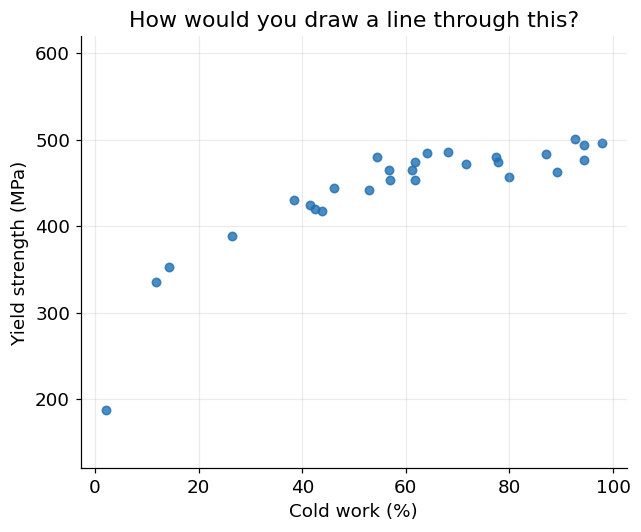

In [2]:
grid = np.linspace(0, 100, 400).reshape(-1, 1)  # Generate the x data span from 0 to 100 - 400 data points
#This grid of 400 is different from the earlier 40 datapoints: it's not data at all, just a dense, smooth set of x-values used purely for plotting

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x_train, y_train, s=30, color="#1f6fb2", alpha=0.8)
ax.set_xlabel("Cold work (%)")
ax.set_ylabel("Yield strength (MPa)")
ax.set_ylim(120, 620)
ax.set_title("How would you draw a line through this?")
plt.tight_layout(); plt.show()

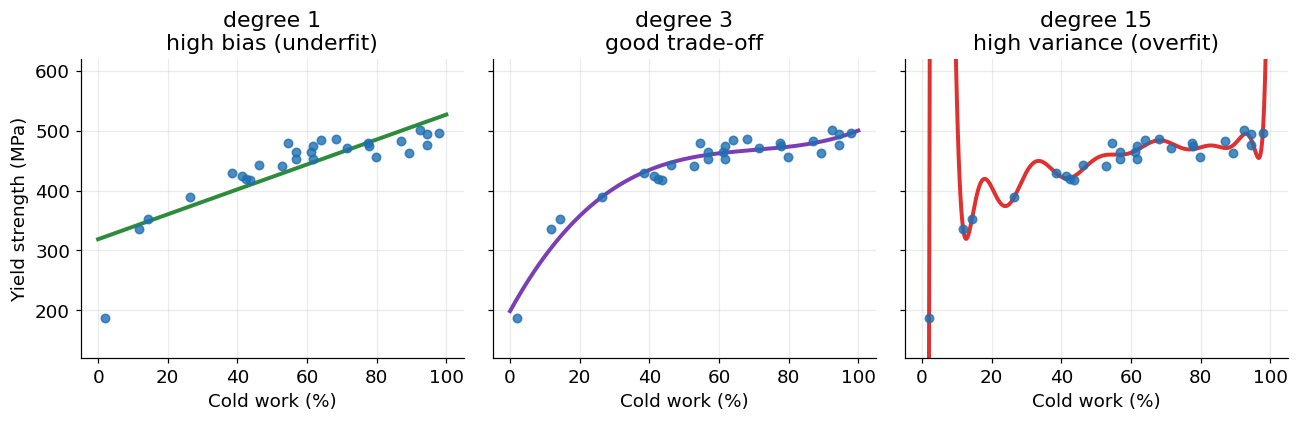

In [3]:
grid = np.linspace(0, 100, 400).reshape(-1, 1)
fits = [(1,  "high bias (underfit)",      "#2e8b3d"),
        (3,  "good trade-off",            "#7b3fb5"),
        (15, "high variance (overfit)",   "#e03131")]  #You can change these values

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (degree, label, colour) in zip(axes, fits):
    model = fit_polynomial(degree, x_train, y_train)
    ax.scatter(x_train, y_train, s=30, color="#1f6fb2", alpha=0.8, zorder=3)
    ax.plot(grid, np.clip(model.predict(grid), 0, 700), color=colour, lw=2.6)
    ax.set_title(f"degree {degree}\n{label}")
    ax.set_xlabel("Cold work (%)"); ax.set_ylim(120, 620)
axes[0].set_ylabel("Yield strength (MPa)")
plt.tight_layout(); plt.show()


## How training error and testing error change as model complexity increases 

Lowest TEST error at degree 3 (test RMSE = 16.8 MPa)


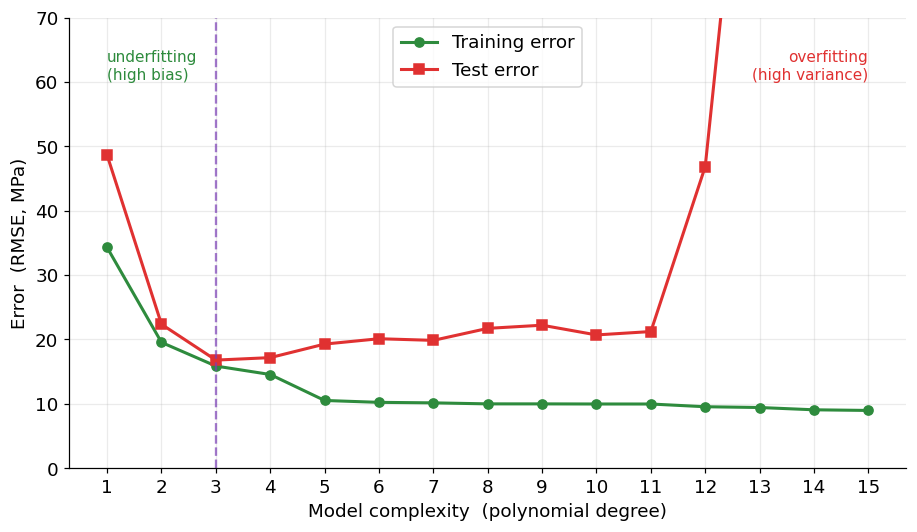

In [4]:
degrees = range(1, 16)  #Polynomial degrees range from 1 to 15

train_rmse, test_rmse = [], []
for d in degrees:
    m = fit_polynomial(d, x_train, y_train)   #fit a polynomial for each degree
    train_rmse.append(np.sqrt(mean_squared_error(y_train, m.predict(x_train.reshape(-1,1))))) #add the rmse values to an array
    test_rmse.append( np.sqrt(mean_squared_error(y_test,  m.predict(x_test.reshape(-1,1)))))

best = int(np.argmin(test_rmse))
print(f"Lowest TEST error at degree {list(degrees)[best]} "
      f"(test RMSE = {test_rmse[best]:.1f} MPa)")

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(list(degrees), train_rmse, "o-", color="#2e8b3d", lw=2, label="Training error")
ax.plot(list(degrees), test_rmse,  "s-", color="#e03131", lw=2, label="Test error")
ax.set_ylim(0, 70)                                   # hide the runaway overfit tail
ax.axvline(list(degrees)[best], ls="--", color="#7b3fb5", alpha=0.7)
ax.text(1, 65, "underfitting\n(high bias)",  color="#2e8b3d", fontsize=10, va="top")
ax.text(15, 65, "overfitting\n(high variance)", color="#e03131", fontsize=10, va="top", ha="right")
ax.set_xlabel("Model complexity  (polynomial degree)")
ax.set_ylabel("Error  (RMSE, MPa)"); ax.set_xticks(list(degrees))
ax.legend(loc="upper center"); plt.tight_layout(); plt.show()


## The tables listing metrics


In [5]:
import pandas as pd

def scores(degree):
    m = fit_polynomial(degree, x_train, y_train)
    p_tr = m.predict(x_train.reshape(-1, 1))
    p_te = m.predict(x_test.reshape(-1, 1))
    return {"train R2": r2_score(y_train, p_tr),
            "test R2":  r2_score(y_test,  p_te),
            "train RMSE": np.sqrt(mean_squared_error(y_train, p_tr)),
            "test RMSE":  np.sqrt(mean_squared_error(y_test,  p_te)),
            "test MAE":   mean_absolute_error(y_test, p_te)}

summary = pd.DataFrame({f"degree {d}": scores(d) for d in [1, 3, 15]}).round(2).T
summary


,train R2,test R2,train RMSE,test RMSE,test MAE
degree 1,0.71,0.76,34.29,48.63,34.94
degree 3,0.94,0.97,15.87,16.79,13.02
degree 15,0.98,-28.04,8.97,534.02,258.44


### Residual analysis - the model's leftovers



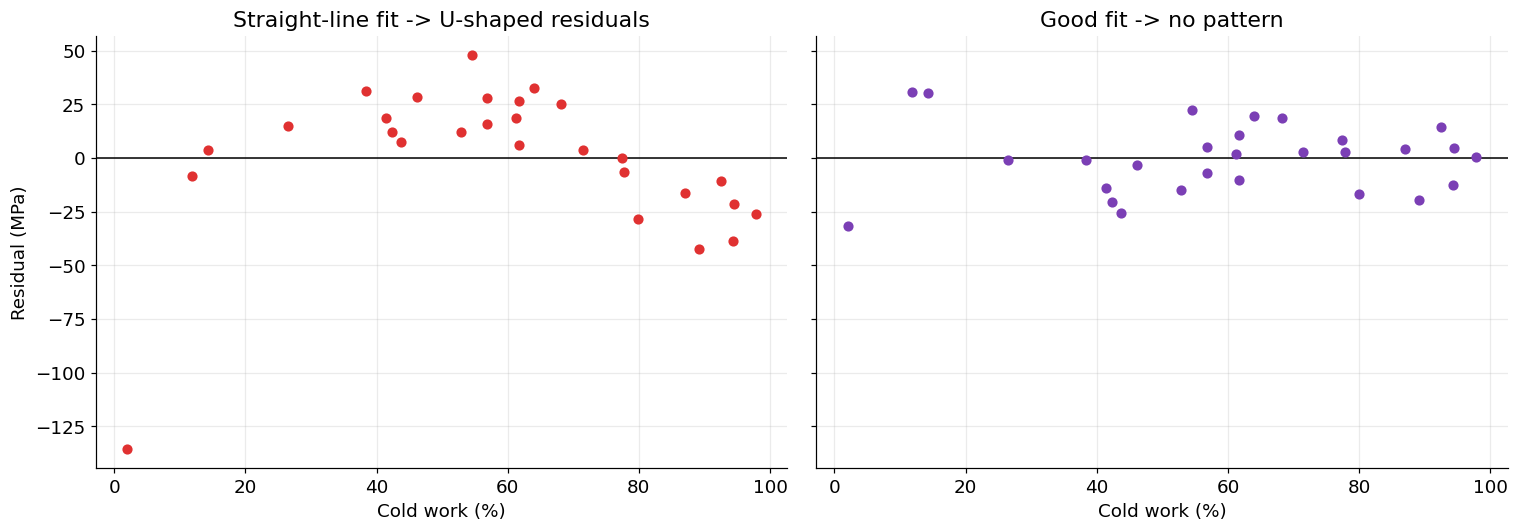

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
panels = [(1, "#e03131", "Straight-line fit -> U-shaped residuals"),
          (3, "#7b3fb5", "Good fit -> no pattern")]
for ax, (degree, colour, title) in zip(axes, panels):
    m = fit_polynomial(degree, x_train, y_train)
    residual = y_train - m.predict(x_train.reshape(-1, 1))   # actual - predicted
    ax.scatter(x_train, residual, color=colour, s=32, zorder=3)
    ax.axhline(0, color="k", lw=1)
    ax.set_title(title); ax.set_xlabel("Cold work (%)")
axes[0].set_ylabel("Residual (MPa)")
plt.tight_layout(); plt.show()


## The same idea, everywhere: 
## K-means

The **elbow method** you already know is really just looking for that balance point.

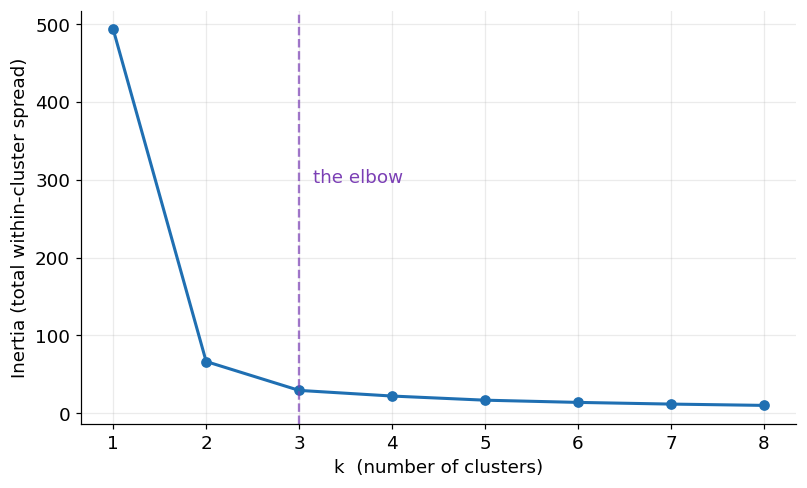

In [7]:
from sklearn.cluster import KMeans


blob = np.random.RandomState(0)
X = np.vstack([blob.normal([0.3, 1.5], 0.18, (40, 2)),
               blob.normal([1.6, 4.5], 0.40, (60, 2)),
               blob.normal([2.1, 5.8], 0.35, (40, 2))])   # 3 natural groups

ks = range(1, 9)
inertia = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).inertia_ for k in ks]

#If your code throws an error here, most likely it is to do with the argument `n_init' : 
#as newer versions of sklearn has changed the default of n_init='auto'
#If there are warnings, you can ignore them

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(list(ks), inertia, "o-", color="#1f6fb2", lw=2)
ax.axvline(3, ls="--", color="#7b3fb5", alpha=0.7)
ax.text(3.15, max(inertia)*0.6, "the elbow", color="#7b3fb5")
ax.set_xlabel("k  (number of clusters)")
ax.set_ylabel("Inertia (total within-cluster spread)")
plt.tight_layout(); plt.show()


# Cross validation (Next page)

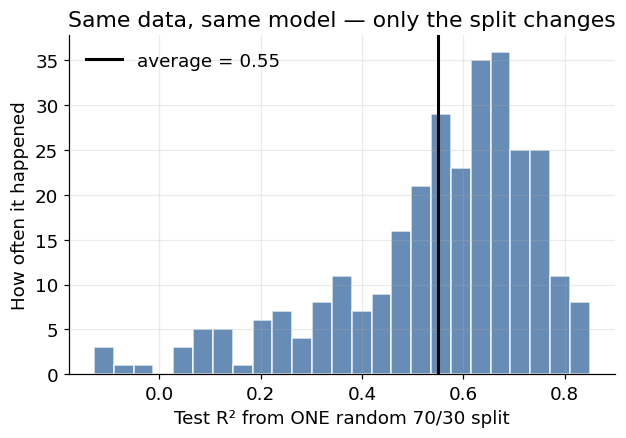

Worst split R² = -0.13
Best  split R² = 0.85
So the 'score' of this model could be reported as anything from -0.13 to 0.85 — just by choosing the split!


In [8]:
from sklearn.model_selection import train_test_split
# One small, synthetic dataset (illustrative — not real measurements).
rng = np.random.default_rng(0)
n = 40
x = np.sort(rng.uniform(0, 1, n))
true = np.sin(2.2*np.pi*x)*0.8 + 1.5*x          # the (unknown) true relationship
y = true + rng.normal(0, 0.35, n)               # our noisy measurements
X = x.reshape(-1, 1)

# A fixed, reasonable model. We never change it.
model = make_pipeline(PolynomialFeatures(4), LinearRegression())

# Try 300 different random 70/30 splits and record each test score.
scores = []
for seed in range(300):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, random_state=seed)
    model.fit(Xtr, ytr)
    scores.append(r2_score(yte, model.predict(Xte)))
scores = np.array(scores)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.hist(scores, bins=25, color="#4C78A8", alpha=0.85, edgecolor="white")
ax.axvline(scores.mean(), color="black", lw=2, label=f"average = {scores.mean():.2f}")
ax.set_xlabel("Test R\u00b2 from ONE random 70/30 split")
ax.set_ylabel("How often it happened")
ax.set_title("Same data, same model \u2014 only the split changes")
ax.legend(frameon=False)
plt.show()

print(f"Worst split R\u00b2 = {scores.min():.2f}")
print(f"Best  split R\u00b2 = {scores.max():.2f}")
print(f"So the 'score' of this model could be reported as anything from "
      f"{scores.min():.2f} to {scores.max():.2f} \u2014 just by choosing the split!")


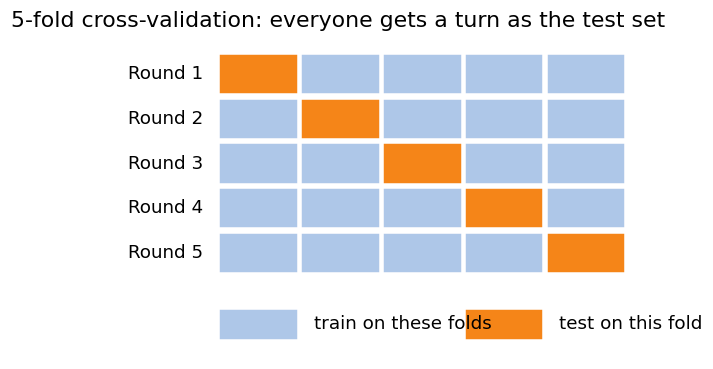

In [9]:
# A schematic of 5-fold cross-validation (a diagram, not a computation).
from matplotlib.patches import Rectangle
K = 5
fig, ax = plt.subplots(figsize=(7.2, 3.8))
for row in range(K):
    for col in range(K):
        val = (col == row)
        ax.add_patch(Rectangle((col, K-1-row), 0.96, 0.9,
                     facecolor="#F58518" if val else "#AEC7E8", edgecolor="white"))
    ax.text(-0.2, K-1-row+0.45, f"Round {row+1}", ha="right", va="center")
# little legend
ax.add_patch(Rectangle((0, -1.5), 0.96, 0.7, facecolor="#AEC7E8", edgecolor="white"))
ax.text(1.15, -1.15, "train on these folds", va="center")
ax.add_patch(Rectangle((3.0, -1.5), 0.96, 0.7, facecolor="#F58518", edgecolor="white"))
ax.text(4.15, -1.15, "test on this fold", va="center")
ax.set_xlim(-2.3, K+0.2); ax.set_ylim(-1.9, K+0.3); ax.axis("off")
ax.set_title("5-fold cross-validation: everyone gets a turn as the test set")
plt.show()